# Limpieza y Análisis de Datos con Vino

Este notebook trabaja con el archivo `data\winemag-data-130k-v2.csv`.

Objetivos:
1. Impotación de librerias
2. Cargar datos y explorarlos.
3. Verificar tipos de datos
4. Limpieza y prepación de datos
5. Verificar valores nulos
6. Normalizar/Limpiar columnas
7. Crear columnas derivadas
8. Estadisticas globales
9. Análisis por país o provincia
10. Variedad de uva (variety)
11. Relación entre precio y puntuación
12. Análisis de longitud de reseña
13. Uno de NumPy para analisis
14. Hacer un mini análisis final.

## 1. Impotación de librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar de datos y exploración.

In [2]:

# Cargar el CSV (si lo tienes guardado como 'wines.csv')
df = pd.read_csv("data/winemag-data-130k-v2.csv")

# Mostrar primeras filas
print(df.head())

# Ver información general
print(df.info())


   id   country                                        description  \
0   0     Italy  Aromas include tropical fruit, broom, brimston...   
1   1  Portugal  This is ripe and fruity, a wine that is smooth...   
2   2        US  Tart and snappy, the flavors of lime flesh and...   
3   3        US  Pineapple rind, lemon pith and orange blossom ...   
4   4        US  Much like the regular bottling from 2012, this...   

                          designation  points  price           province  \
0                        Vulkà Bianco      87    NaN  Sicily & Sardinia   
1                            Avidagos      87   15.0              Douro   
2                                 NaN      87   14.0             Oregon   
3                Reserve Late Harvest      87   13.0           Michigan   
4  Vintner's Reserve Wild Child Block      87   65.0             Oregon   

              region_1           region_2         taster_name  \
0                 Etna                NaN       Kerin O’Keefe  

## 3.Verificar tipos de datos

In [3]:

print("Tipos de datos (antes) de las columnas:")
print(df.dtypes)



Tipos de datos (antes) de las columnas:
id                         int64
country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object


## 4. Limpieza y preparación de datos

In [4]:

# Convertir y asegurar que las  columnas numéricas puedan venir como texto
df['id'] = pd.to_numeric(df['id'], errors='coerce').astype('Int64')
df['price'] = pd.to_numeric(df['price'], errors='coerce').astype(float)
df['points'] = pd.to_numeric(df['points'], errors='coerce').astype('Int64')

# Puede tener mezcla de enteros y strings -> forzamos conversión segura
df = df.astype({col: "string" for col in df.select_dtypes(include="object").columns})

print("TIPOS DESPUÉS:")
print(df.dtypes)

display(df.head())


TIPOS DESPUÉS:
id                                Int64
country                  string[python]
description              string[python]
designation              string[python]
points                            Int64
price                           float64
province                 string[python]
region_1                 string[python]
region_2                 string[python]
taster_name              string[python]
taster_twitter_handle    string[python]
title                    string[python]
variety                  string[python]
winery                   string[python]
dtype: object


,id,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,<NA>,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,<NA>,<NA>,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",<NA>,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,<NA>,Alexander Peartree,<NA>,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## 5. Verificar valores nulos

In [5]:
print("Valores nulos por columna:")
#Conteo valores nulos
print(df.isna().sum())

Valores nulos por columna:
id                           0
country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


## 6.Normalizar/Limpiar columnas 

In [6]:

#Eliminar Nan de paises
df['country'] = df['country'].fillna("Desconocido")

# Capitalizar paises
df['country'] = df['country'].astype(str).str.capitalize()

# Quitar espacios en variety
df['variety'] = (
    df['variety']
        .astype(str)
        .str.strip()
        .str.title()
        .str.replace(' ', '', regex=False)
)

print("Capitalizar paises: ")

print(df['country'].head())

print("Quitar espacios variety: ")

print(df['variety'].head())


##Limpieza de columnas duplicadas
duplicados = df[df.duplicated()]

print("Filas duplicadas detectadas:")
display(duplicados)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

print("Tamaño tras eliminar duplicados:", df.shape)

print(df.head)



Capitalizar paises: 
0       Italy
1    Portugal
2          Us
3          Us
4          Us
Name: country, dtype: object
Quitar espacios variety: 
0       WhiteBlend
1    PortugueseRed
2        PinotGris
3         Riesling
4        PinotNoir
Name: variety, dtype: object
Filas duplicadas detectadas:


,id,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery


Tamaño tras eliminar duplicados: (129971, 14)
<bound method NDFrame.head of             id   country                                        description  \
0            0     Italy  Aromas include tropical fruit, broom, brimston...   
1            1  Portugal  This is ripe and fruity, a wine that is smooth...   
2            2        Us  Tart and snappy, the flavors of lime flesh and...   
3            3        Us  Pineapple rind, lemon pith and orange blossom ...   
4            4        Us  Much like the regular bottling from 2012, this...   
...        ...       ...                                                ...   
129966  129966   Germany  Notes of honeysuckle and cantaloupe sweeten th...   
129967  129967        Us  Citation is given as much as a decade of bottl...   
129968  129968    France  Well-drained gravel soil gives this wine its c...   
129969  129969    France  A dry style of Pinot Gris, this is crisp with ...   
129970  129970    France  Big, rich and off-dry, this i

## 7. Crear columnas derivadas

In [7]:
# booleano si el vino tiene precio registrado)
df['has_price'] = df['price'].notnull()

print("Tiene precio registrado?:")

print(df['has_price'].head())

# Combinación de regiones
df['region_combined'] = df['region_1'].fillna('') + ' | ' + df['region_2'].fillna('')


print("Combinación de regiones:")

print(df['region_combined'].head())


# longitud del texto de descripcion
df['review_lenght'] = df['description'].str.len()


print("Longitud del texto descriptivo:")

print(df['review_lenght'].head())

Tiene precio registrado?:
0    False
1     True
2     True
3     True
4     True
Name: has_price, dtype: bool
Combinación de regiones:
0                                  Etna | 
1                                       | 
2    Willamette Valley | Willamette Valley
3                   Lake Michigan Shore | 
4    Willamette Valley | Willamette Valley
Name: region_combined, dtype: string
Longitud del texto descriptivo:
0    172
1    227
2    186
3    199
4    249
Name: review_lenght, dtype: Int64


## 8. Estadisticas globales

In [8]:
#Calcular la media, mediana, desviación estándar, mínimo/máximo de variables numéricas: points, price, review_length.
print("--POINTS--")
media = df['points'].mean()
print("La media de puntos:" , media)
mediana = df['points'].median()
print("La mediana de puntos: " ,  mediana)
max = df['points'].max()
print("El máximo de puntos: " ,  max)
min = df['points'].min()
print("El mínimo de puntos: " ,  min)
des = df['points'].std()
print("La desviación estándar de puntos: " ,  des)


print("--PRICE--")
df_filtrado = df[df['has_price'] == True]['price']
media = df_filtrado.mean()
print("La media de precios:" , media)
mediana = df_filtrado.median()
print("La mediana de precios: " ,  mediana)
max = df_filtrado.max()
print("El máximo de precios: " ,  max)
min = df_filtrado.min()
print("El mínimo de precios: " ,  min)
des = df_filtrado.std()
print("La desviación estándar de precios: " ,  des)

print("--REVIEW LENGTH--")

media = df['review_lenght'].mean()
print("La media de reseñas:", media)
mediana = df['review_lenght'].median()
print("La mediana de reseñas: " ,  mediana)
max = df['review_lenght'].max()
print("El máximo de reseñas: " ,  max)
min = df['review_lenght'].min()
print("El mínimo de reseñas: " ,  min)
des = df['review_lenght'].std()
print("La desviación estándar de precios: " ,  des)

print("------------------------------------------------------")
print("--ESTADÍSTICAS BÁSICAS--")
registros = len(df)
print("Cantidad registros:", registros)

print("--PAISES DISTINTOS--")
cantidad_p = df['country'].nunique()
print("Paises distintos:" , cantidad_p)

print("--BODEGAS DISTINTAS--")
cantidad_w = df['winery'].nunique()
print("Bodegas distintas:" , cantidad_w)


--POINTS--
La media de puntos: 88.44713820775404
La mediana de puntos:  88.0
El máximo de puntos:  100
El mínimo de puntos:  80
La desviación estándar de puntos:  3.0397302029160036
--PRICE--
La media de precios: 35.363389129985535
La mediana de precios:  25.0
El máximo de precios:  3300.0
El mínimo de precios:  4.0
La desviación estándar de precios:  41.02221766808723
--REVIEW LENGTH--
La media de reseñas: 242.60106485292874
La mediana de reseñas:  237.0
El máximo de reseñas:  829
El mínimo de reseñas:  20
La desviación estándar de precios:  66.58427575902327
------------------------------------------------------
--ESTADÍSTICAS BÁSICAS--
Cantidad registros: 129971
--PAISES DISTINTOS--
Paises distintos: 44
--BODEGAS DISTINTAS--
Bodegas distintas: 16757


## 9. Análisis por país o provincia


In [9]:

# Agrupar por country (o province) para calcular:
paises = df.groupby("country")

# número de vinos registrados
vinos_registrados = paises.size()   # cuenta filas por país
print("\n------VINOS REGISTRADOS------")
print("\nVinos registrados por país:" , vinos_registrados)

# precio medio (has_price) 
# Utilizamos el has_price porque quitamos los nulos en el apartado 7
mediana_paises = paises["price"].median()
print("\n------MEDIANA DE PRECIOS POR PAISES------")
print("\nEl precio medio por país es: " ,  mediana_paises)

# puntuación media (points)
mediana_points = paises["points"].median()
print("\n------MEDIANA DE PUNTOS POR PAISES-------")
print("\nLos puntos medio por país es: " ,  mediana_points)

# Ordenar países de mayor a menor según puntuación media o precio medio.
print("\n---- PAISES ORDENADOS POR PRECIO (mayor → menor) ----")
paises = mediana_paises.sort_values(ascending = False)
print(paises)
print("\n----PAISES SEGÚN LOS PUNTOS (mayor → menor)----")
paises = mediana_points.sort_values(ascending = False)
print(paises)

# Reflexionar: ¿qué países destacan en precio vs. puntuación?
division= mediana_points/mediana_paises
descatados = division.sort_values(ascending = False)
print("\n----PAISES CON MAYOR CANTIDAD DE PRECIOS Y PUNTOS-----")
print(descatados)





------VINOS REGISTRADOS------

Vinos registrados por país: country
Argentina                  3800
Armenia                       2
Australia                  2329
Austria                    3345
Bosnia and herzegovina        2
Brazil                       52
Bulgaria                    141
Canada                      257
Chile                      4472
China                         1
Croatia                      73
Cyprus                       11
Czech republic               12
Desconocido                  63
Egypt                         1
England                      74
France                    22093
Georgia                      86
Germany                    2165
Greece                      466
Hungary                     146
India                         9
Israel                      505
Italy                     19540
Lebanon                      35
Luxembourg                    6
Macedonia                    12
Mexico                       70
Moldova                      59
Moro

## 10. Variedad de uva (variety)



In [10]:
#Agrupar por variety para calcular:
agrupacion_variety =  df.groupby("variety")

#número de vinos
vinos_registrados = agrupacion_variety.size()   # cuenta filas por país
print("\n------VINOS REGISTRADOS------")
print("\nVinos registrados por variación de vinos:" , vinos_registrados)

#puntuación media (points)

mediana_points = agrupacion_variety["points"].median()
print("\n------MEDIANA DE PUNTOS POR PAISES-------")
print("\nLos puntos medio por variación de vinos son: " ,  mediana_points)

#precio medio (price)

mediana_price = agrupacion_variety["price"].median()
print("\n------MEDIANA DE PRECIO POR VARIACIÓN DE VINOS -------")
print("\nEL PRECIO  medio por variación de vinos es: " ,  mediana_price)


#Identificar las variedades con mayor puntuación media, y las que están por debajo del promedio.
print("\n----  ORDENADOS POR PRECIO (mayor → menor) ----")
ordenar_agrupacion_variety = mediana_price.sort_values(ascending = False)
print(ordenar_agrupacion_variety)

print("\n----  PAISES POR DEBAJO DEL PROMEDIO----")
promedio = mediana_points.mean()
paises_debajo_promedio = mediana_points[mediana_points <= promedio]
print(paises_debajo_promedio)




------VINOS REGISTRADOS------

Vinos registrados por variación de vinos: variety
<Na>              1
Abouriou          3
Agiorgitiko      63
Aglianico       359
Aidani            1
               ... 
Zinfandel      2714
Zlahtina          2
Zweigelt        209
Çalkarası         2
Žilavka           1
Length: 708, dtype: int64

------MEDIANA DE PUNTOS POR PAISES-------

Los puntos medio por variación de vinos son:  variety
<Na>           88.0
Abouriou       87.0
Agiorgitiko    87.0
Aglianico      89.0
Aidani         82.0
               ... 
Zinfandel      88.0
Zlahtina       86.0
Zweigelt       89.0
Çalkarası      86.5
Žilavka        88.0
Name: points, Length: 708, dtype: Float64

------MEDIANA DE PRECIO POR VARIACIÓN DE VINOS -------

EL PRECIO  medio por variación de vinos es:  variety
<Na>           17.0
Abouriou       15.0
Agiorgitiko    20.0
Aglianico      33.5
Aidani         27.0
               ... 
Zinfandel      28.0
Zlahtina       14.5
Zweigelt       18.0
Çalkarası      19.0
Ži

## 11. Relación entre precio y puntuación

In [35]:


#Verificar si los vinos con mayor points tienden a tener mayor price, sin contar el outlier.




#Verificar correlación entre price y points usando NumPy (por ejemplo np.corrcoef()).

precio_filtrado = df[df["price"] < 1000] 
cols=["price","points"]
corr = precio_filtrado[cols].corr()
print("Vinos que tienden a tener mayor price: ")
print(corr)


#Crear una nueva columna price_per_point = price / points (solo donde price no está nulo) y analizar su distribución.
df_con_precio = df[df['has_price'] == True].copy()
df_con_precio["price_per_point"] = df_con_precio["price"] / df_con_precio["points"]



# Viendo el historigrama eliminamos la columna del valor del vino de 3000

# Tomar los outlier como los mayores de 200?, preguntar despues.
df_filtrado = df[(df['has_price'] == True) & (df["price"] < 1000)].copy()
df_filtrado["price_per_point"] = df_filtrado["price"] / df_filtrado["points"]



df_mas_de_200 = len(df[df["price"] > 250])
print("Hay cantidad de vinos que valen mas de 1000 euros: ", df_mas_de_200)


# Hay 14 vinos con mas de 1000 euros de precio 
# Hay 454 vinos con mas de 250 euros de precio 
# Hay 129971 vinos en total 


#convertir de a numero el tipo de vino, Crear una correlacion entre:

#Crear una correlacion entre: precio - tipo de vino - viñedo - pais

precio_filtrado = df[df["price"] < 1000].copy()

# precio_variety = precio_filtrado.groupby("variety")["price"].median()
# precio_winery = precio_filtrado.groupby("winery")
# precio_country = precio_filtrado.groupby("country")["price"].median()

precio_filtrado["variety_num"] = pd.factorize(precio_filtrado["variety"])[0]
precio_filtrado["winery_num"] = pd.factorize(precio_filtrado["winery"])[0]
precio_filtrado["country_num"] = pd.factorize(precio_filtrado["country"])[0]

# Columnas para correlación
cols = ["price", "variety_num", "winery_num", "country_num"]

# Calcular matriz de correlación
corr = precio_filtrado[cols].corr()
print(corr)


Vinos que tienden a tener mayor price: 
           price    points
price   1.000000  0.466528
points  0.466528  1.000000
Hay cantidad de vinos que valen mas de 1000 euros:  454
                price  variety_num  winery_num  country_num
price        1.000000    -0.052861   -0.041420    -0.057839
variety_num -0.052861     1.000000    0.076887     0.102060
winery_num  -0.041420     0.076887    1.000000     0.110787
country_num -0.057839     0.102060    0.110787     1.000000


## 12. Histograma

Historigramas antes de eliminar el outlier


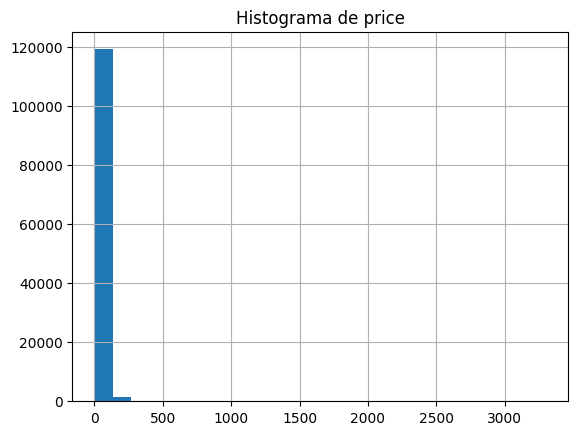

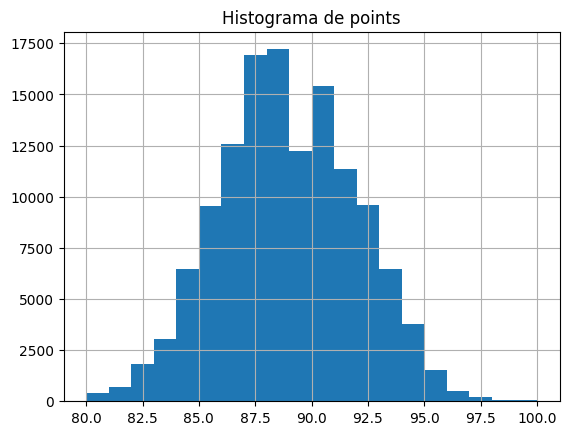

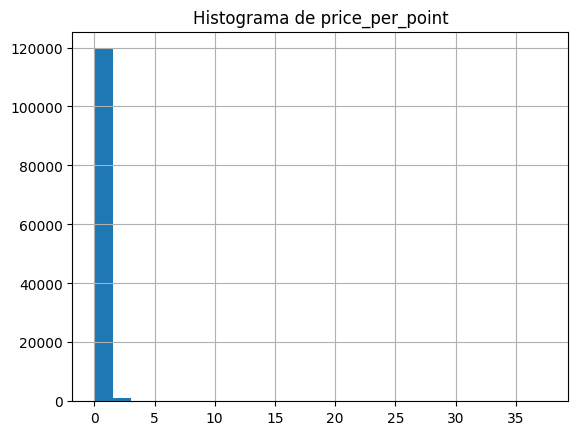

Historigramas despues de eliminar el outlier


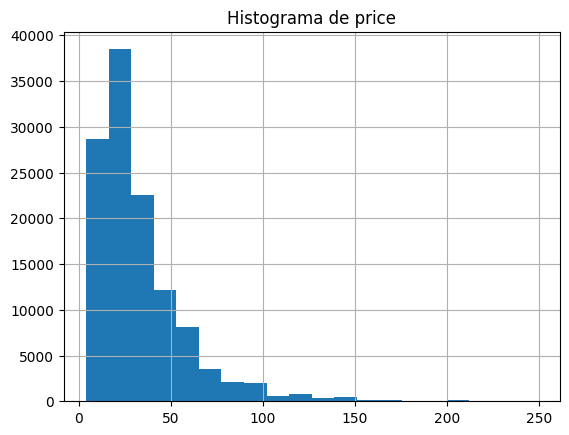

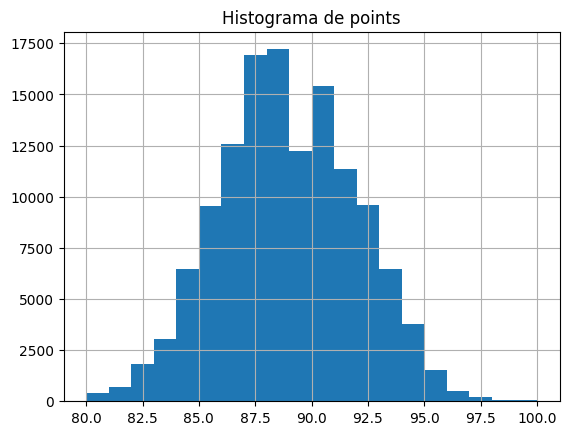

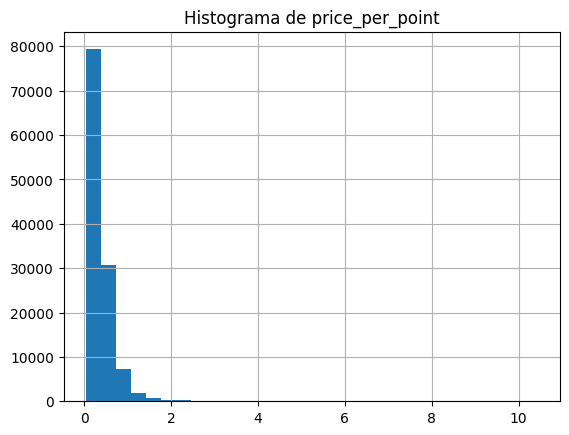

In [ ]:
# Haciendo el historigrama podemos ver que hay un outlier que es un vino de 3000 euros que nos distorsiona todos
# los valores de la media, por lo que para que no afecte a las correlaciones, eliminaremos este vino
# al calcularlo

points = df['points']
prices = df[df["has_price"] == True]["price"]

price_per_point = df_con_precio["price_per_point"]
cols = [prices, points, price_per_point ]

print("Historigramas antes de eliminar el outlier")
for c in cols:
    if c.name == "price":
        c.hist(bins=25, range=(c.min(), c.max()))
    elif c.name == "price_per_point":
        c.hist(bins=25, range=(c.min(), c.max())) 
    else:
        c.hist(bins=20)
    plt.title(f"Histograma de {c.name}")
    plt.show()



print("Historigramas despues de eliminar el outlier")
precio_filtrado = df[(df['has_price'] == True) & (df["price"] < 250)]["price"]
price_per_point = df_filtrado["price_per_point"]

cols = [precio_filtrado, points, price_per_point]

for c in cols:
    if c.name == "precio_filtrado":
        c.hist(bins=30, range=(c.min(), c.max()))
    elif c.name == "price_per_point":
        c.hist(bins=30, range=(c.min(), c.max())) 
    else:
        c.hist(bins=20)
    plt.title(f"Histograma de {c.name}")
    plt.show()


## 13. Análisis de longitud de reseña

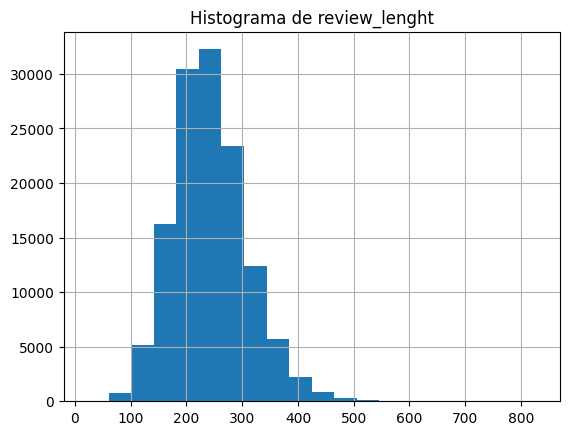

KeyError: 'review_length'

In [ ]:

# Histo
review_lenght = df["review_lenght"]

review_lenght.hist(bins=20)
plt.title(f"Histograma de {review_lenght.name}")
plt.show()



## 14. Uno de NumPy para analisis

## 15. Hacer un mini análisis final.